# 2. Prophet Model

In this notebook, we load our preprocessed time-series data and train **cluster-specific** Prophet models. Facebook Prophet is highly effective at capturing multiple seasonalities (daily and weekly), making it ideal for forecasting the distinct behavioral patterns of our clusters.

## 1. Imports and Data Loading
We import `pandas` for data handling, `prophet` for our core forecasting algorithm, and `scikit-learn` strictly for evaluating our business metric (MAPE). We then load our highly compressed Parquet data alongside our predefined client clusters.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import logging
import seaborn as sns

from tqdm import tqdm
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# Suppress verbose Prophet/stan console warnings to keep the notebook clean
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# Load Data (Cluster column is already in the parquet from notebook 0.5)
print("Loading processed data...")
df_long = pd.read_parquet('../Datasets/processed_electricity_data.parquet')
cluster_map = df_long[['ClientID', 'Cluster']].drop_duplicates()

/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Loading processed data...


### 2. Cluster-Based Prophet Modeling
Unlike standard regression, Facebook Prophet decomposes time series into trend, seasonality, and holidays. To satisfy the requirement of building **one model per cluster**, we aggregate the historical training data by calculating the average consumption for each cluster at each timestamp. 
We then train 5 distinct Prophet models. This captures the unique daily and weekly seasonalities of each consumer group (e.g., standard business vs. night-shift) while keeping computational latency extremely low.

In [2]:
# ---------------------------------------------------------
# Per-Client Standardization & Cluster Aggregation
# ---------------------------------------------------------
print("Standardizing each client to extract behavioral shapes...")
df_long = df_long.sort_values(by=['ClientID', 'Date'])
client_scalers = {}
df_long['Consumption_Scaled'] = np.nan

for client in tqdm(df_long['ClientID'].unique(), desc="Scaling Clients"):
    mask = df_long['ClientID'] == client
    scaler = StandardScaler()
    df_long.loc[mask, 'Consumption_Scaled'] = scaler.fit_transform(
        df_long.loc[mask, 'Consumption'].values.reshape(-1, 1)
    ).flatten()
    client_scalers[client] = scaler

print("\nAggregating historical SCALED data by Cluster...")

# ---------------------------------------------------------
# Weather regressors for Prophet (no Temp_National_Avg — multicollinear with HDH/CDH)
# Weather lags and anomalies are NOT multicollinear: they are shifted/transformed
# ---------------------------------------------------------
weather_regressors = ['HDH', 'CDH',
                      'HDH_lag24h', 'CDH_lag24h',
                      'HDH_anomaly', 'CDH_anomaly']
weather_regressors = [c for c in weather_regressors if c in df_long.columns]

agg_dict = {'Consumption_Scaled': 'mean'}
for col in weather_regressors:
    agg_dict[col] = 'first'

cluster_df = df_long.groupby(['Cluster', 'Date'], observed=True).agg(agg_dict).reset_index()
cluster_df = cluster_df.rename(columns={'Date': 'ds', 'Consumption_Scaled': 'y'})

train_df = cluster_df[cluster_df['ds'].dt.year < 2014].copy()
test_df  = cluster_df[cluster_df['ds'].dt.year >= 2014].copy()

Standardizing each client to extract behavioral shapes...


Scaling Clients: 100%|██████████| 369/369 [00:07<00:00, 50.77it/s]



Aggregating historical SCALED data by Cluster...


In [3]:
# ---------------------------------------------------------
# TRAIN CLUSTER MODELS & FORECAST INDIVIDUAL CLIENTS
# ---------------------------------------------------------
cluster_models = {}
cluster_forecasts = {}

unique_clusters = train_df['Cluster'].dropna().unique()

for cluster_id in tqdm(sorted(unique_clusters), desc="Training Prophet per Cluster"):
    df_train_c = train_df[train_df['Cluster'] == cluster_id]
    df_test_c  = test_df[test_df['Cluster'] == cluster_id]

    # ---------------------------------------------------------
    # Prophet Configuration
    # changepoint_prior_scale=0.05: conservative trend for year-long stability
    # fourier_order=10: captures daily shape without overfitting (24 was extreme)
    # ---------------------------------------------------------
    m = Prophet(changepoint_prior_scale=0.05, uncertainty_samples=0, daily_seasonality=False)
    m.add_seasonality(name='daily', period=1, fourier_order=10) 
    m.add_country_holidays(country_name='PT')
    
    for reg in weather_regressors:
        m.add_regressor(reg)
    
    m.fit(df_train_c)
    cluster_models[cluster_id] = m

    future = df_test_c[['ds'] + weather_regressors].copy()
    forecast = m.predict(future)
    cluster_forecasts[cluster_id] = forecast['yhat'].values


# ---------------------------------------------------------
# CLIENT-LEVEL EVALUATION & METRICS (2014)
# ---------------------------------------------------------
print("\nTranslating cluster patterns to individual client kW forecasts...")
client_results = []

df_test_raw = df_long[df_long['Date'].dt.year >= 2014].copy()

for client in tqdm(df_test_raw['ClientID'].unique(), desc="Evaluating Clients"):
    client_data = df_test_raw[df_test_raw['ClientID'] == client]
    if len(client_data) == 0 or client not in client_scalers: continue
        
    cluster_id = client_data['Cluster'].values[0]
    if pd.isna(cluster_id):
        continue
    
    pattern_forecast = cluster_forecasts[cluster_id][:len(client_data)]
    
    scaler = client_scalers[client]
    y_pred_kw = scaler.inverse_transform(pattern_forecast.reshape(-1, 1)).flatten()
    y_pred_kw = np.maximum(y_pred_kw, 0)
    
    y_true_kw = client_data['Consumption'].values
    nonzero_mask = y_true_kw > 0.1
    
    # ---------------------------------------------------------
    # MAPE (skip near-zero actuals)
    # ---------------------------------------------------------
    if nonzero_mask.sum() > 0:
        mape = np.mean(np.abs((y_true_kw[nonzero_mask] - y_pred_kw[nonzero_mask]) / y_true_kw[nonzero_mask])) * 100
    else:
        mape = 0.0
    
    # ---------------------------------------------------------
    # WMAPE components (gross + signed for Net WMAPE)
    # ---------------------------------------------------------
    abs_error_sum    = np.sum(np.abs(y_true_kw - y_pred_kw))
    signed_error_sum = np.sum(y_pred_kw - y_true_kw)
    actual_sum       = np.sum(y_true_kw)
    client_wmape = (abs_error_sum / actual_sum * 100) if actual_sum > 0 else 0.0
        
    client_results.append({
        'ClientID': client, 
        'MAPE': mape,
        'WMAPE': client_wmape,
        'Abs_Error_Sum': abs_error_sum,
        'Signed_Error_Sum': signed_error_sum,
        'Actual_Sum': actual_sum
    })

# ---------------------------------------------------------
# GLOBAL RESULTS
# ---------------------------------------------------------
pr_results_df = pd.DataFrame(client_results)

print("\n--- PROPHET BENCHMARK RESULTS ---")
print(f"Global Average MAPE: {pr_results_df['MAPE'].mean():.2f}%")

total_abs_error = pr_results_df['Abs_Error_Sum'].sum()
total_actual = pr_results_df['Actual_Sum'].sum()
global_wmape = (total_abs_error / total_actual) * 100 if total_actual > 0 else 0.0
print(f"Global WMAPE: {global_wmape:.2f}%")

# ---------------------------------------------------------
# PERFORMANCE BREAKDOWN BY CLUSTER (Gross + Net WMAPE)
# Net WMAPE: errors cancel within the cluster (over-predictions offset under-predictions)
# ---------------------------------------------------------
pr_results_df = pr_results_df.merge(cluster_map, on='ClientID', how='inner')

print("\n--- PROPHET PERFORMANCE BY CLUSTER ---\n")
summary = pr_results_df.groupby('Cluster').agg(
    n_clients=('ClientID', 'count'),
    Average_MAPE=('MAPE', 'mean'),
    Total_Abs_Error=('Abs_Error_Sum', 'sum'),
    Total_Signed_Error=('Signed_Error_Sum', 'sum'),
    Total_Actual=('Actual_Sum', 'sum')
)
summary['WMAPE'] = (summary['Total_Abs_Error'] / summary['Total_Actual']) * 100
summary['Net_WMAPE'] = (summary['Total_Signed_Error'].abs() / summary['Total_Actual']) * 100
summary = summary.drop(columns=['Total_Abs_Error', 'Total_Signed_Error', 'Total_Actual']).round(2)
print(summary)

Training Prophet per Cluster:   0%|          | 0/5 [00:00<?, ?it/s]10:55:25 - cmdstanpy - INFO - Chain [1] start processing
10:55:46 - cmdstanpy - INFO - Chain [1] done processing
Training Prophet per Cluster:  20%|██        | 1/5 [00:23<01:34, 23.67s/it]10:55:51 - cmdstanpy - INFO - Chain [1] start processing
10:56:34 - cmdstanpy - INFO - Chain [1] done processing
Training Prophet per Cluster:  40%|████      | 2/5 [01:11<01:53, 37.92s/it]10:56:39 - cmdstanpy - INFO - Chain [1] start processing
10:57:57 - cmdstanpy - INFO - Chain [1] done processing
Training Prophet per Cluster:  60%|██████    | 3/5 [02:34<01:56, 58.36s/it]10:58:01 - cmdstanpy - INFO - Chain [1] start processing
10:59:08 - cmdstanpy - INFO - Chain [1] done processing
Training Prophet per Cluster:  80%|████████  | 4/5 [03:45<01:03, 63.49s/it]10:59:13 - cmdstanpy - INFO - Chain [1] start processing
11:00:07 - cmdstanpy - INFO - Chain [1] done processing
Training Prophet per Cluster: 100%|██████████| 5/5 [04:44<00:00, 56.


Translating cluster patterns to individual client kW forecasts...


Evaluating Clients: 100%|██████████| 369/369 [00:01<00:00, 188.83it/s]



--- PROPHET BENCHMARK RESULTS ---
Global Average MAPE: 50.83%
Global WMAPE: 22.19%

--- PROPHET PERFORMANCE BY CLUSTER ---

         n_clients  Average_MAPE  WMAPE  Net_WMAPE
Cluster                                           
0.0             28        136.04  19.49      11.72
1.0             77         87.01  28.14      20.76
2.0             58         51.99  33.24      25.41
3.0             13         60.42  19.35       1.48
4.0            174         20.00  13.71       7.70


## 4. Forecasting Visualization
To visually validate our Prophet models, we plot the actual vs. predicted consumption for one representative client per cluster. 
We reconstruct the specific client's forecast by taking the pure behavioral pattern learned by the cluster's Prophet model and un-scaling it using the client's individual `StandardScaler`. We slice the plot to show only the **last 14 days** to ensure the daily seasonal curves are readable.

Generating validation plots...


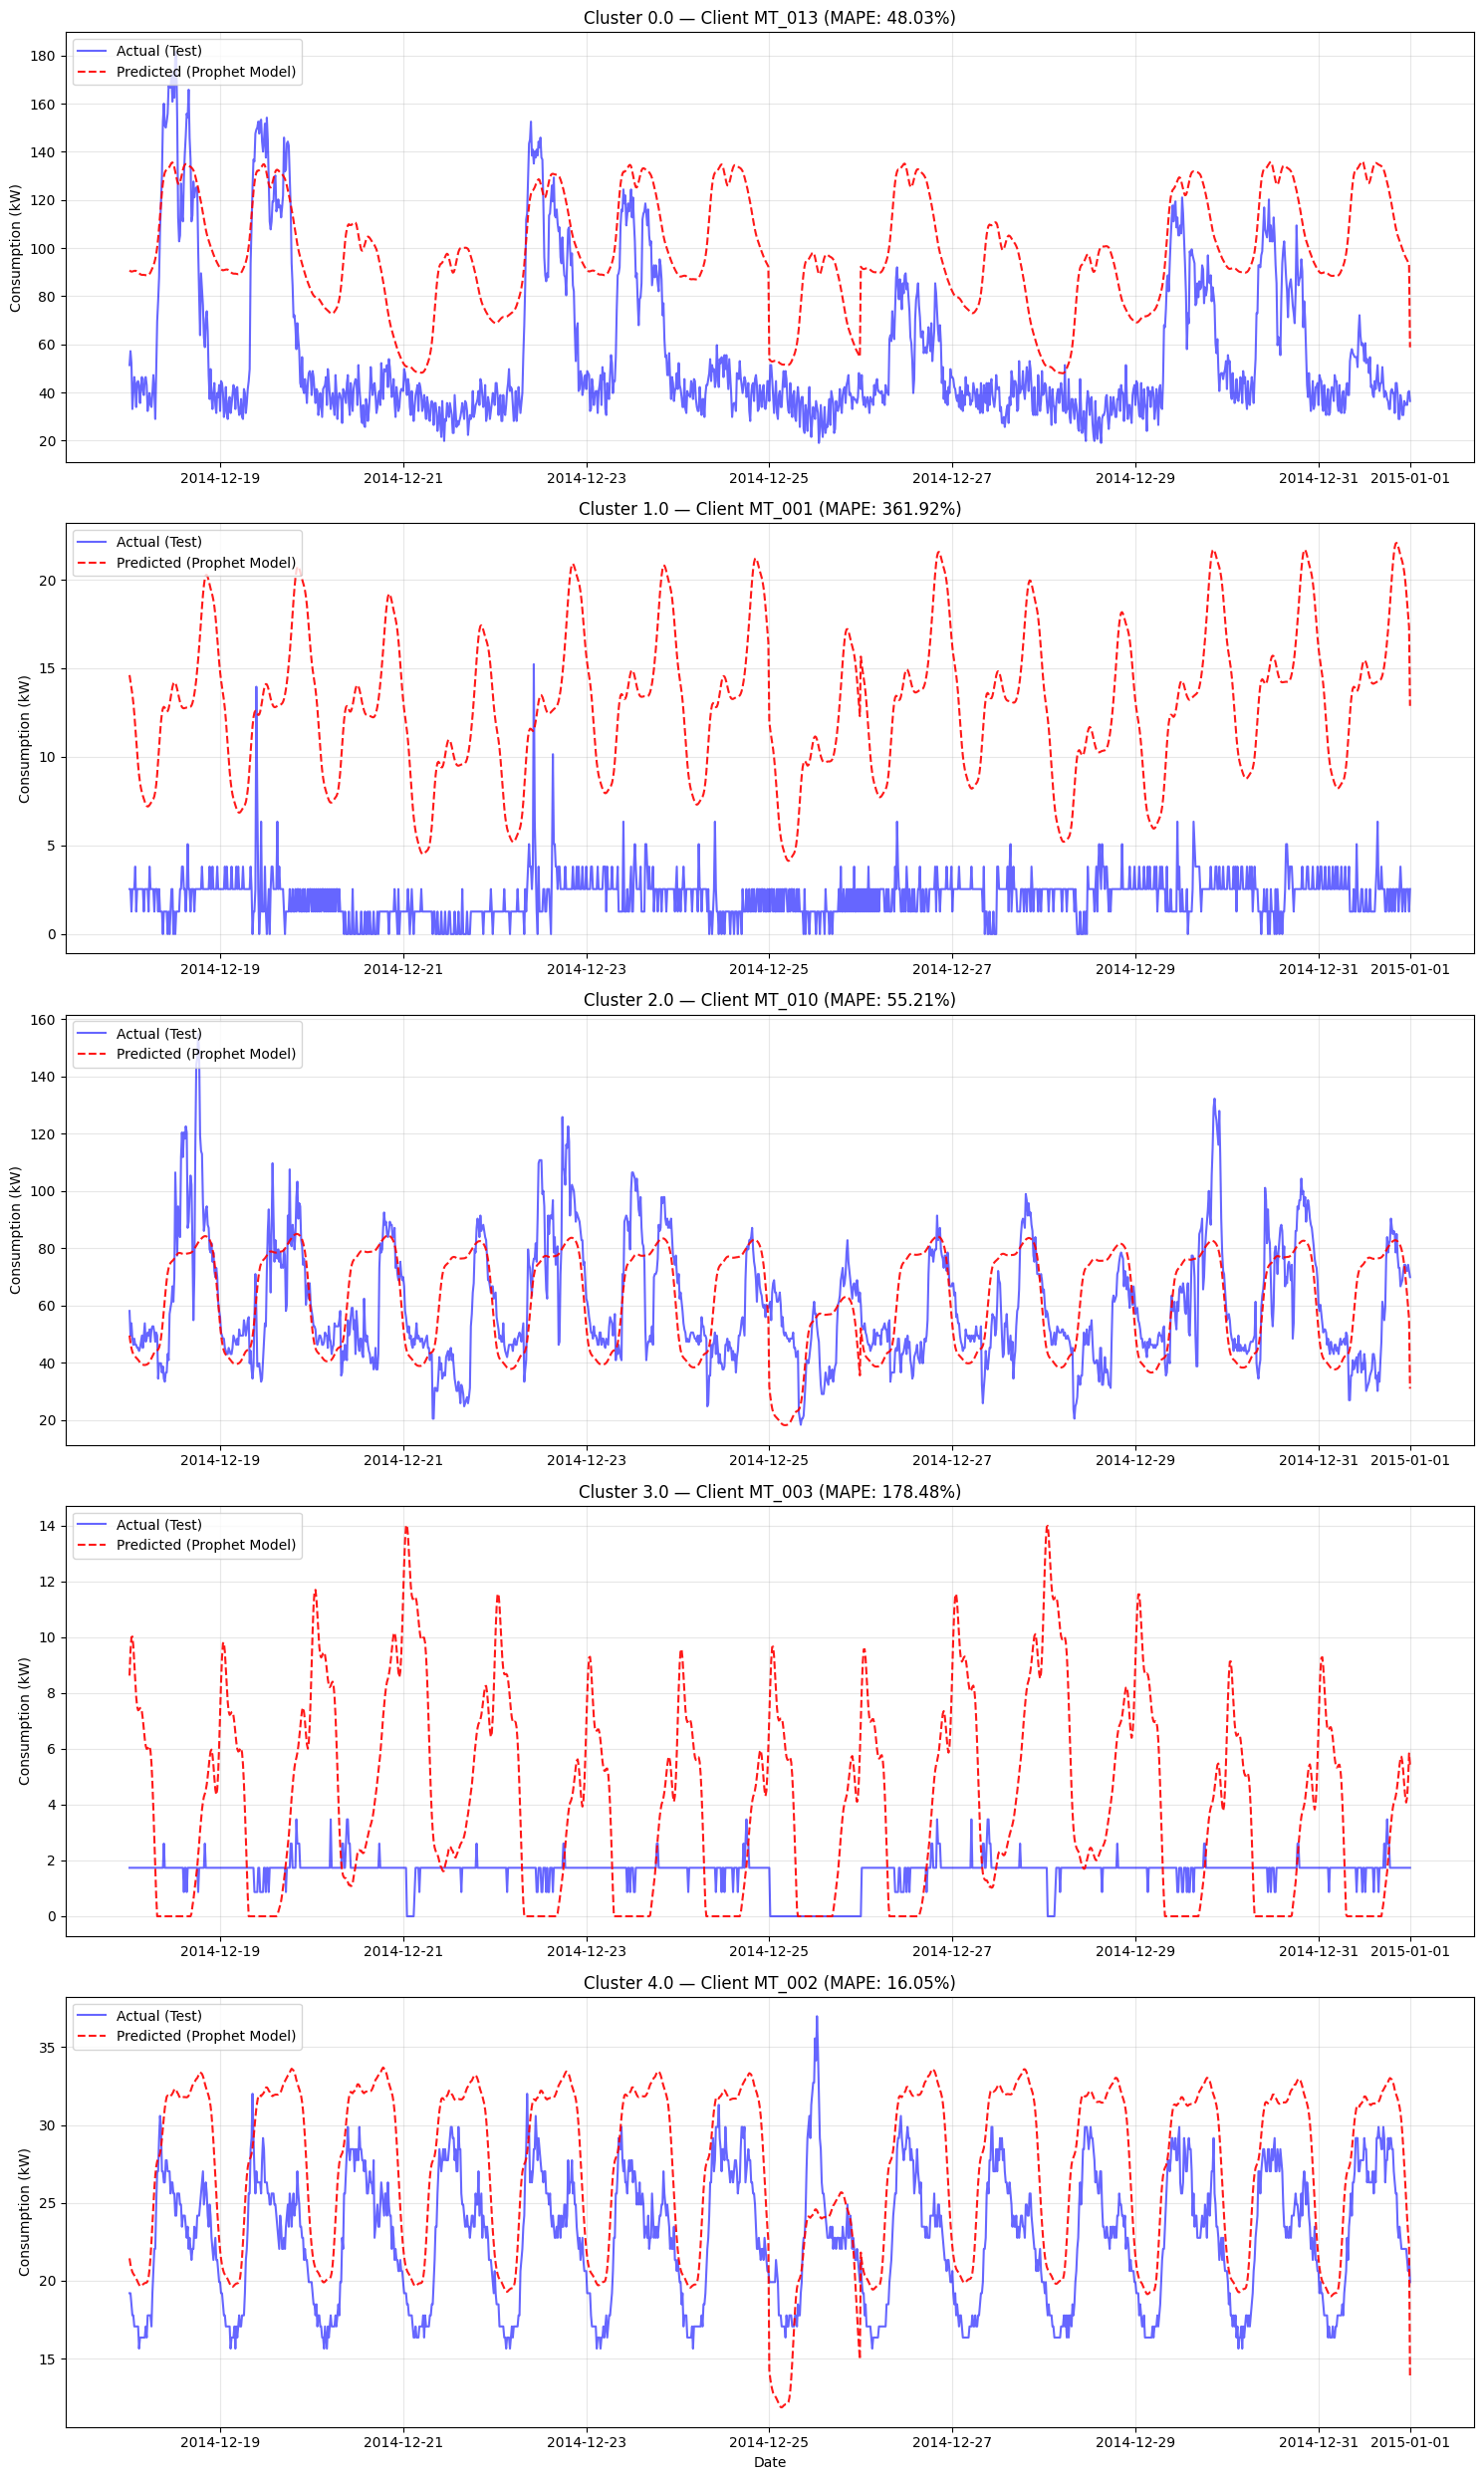

In [4]:
# Visualization: One Client per Cluster
print("Generating validation plots...")

# 1. Select one representative client for each cluster dynamically
cluster_representatives = df_test_raw.groupby('Cluster')['ClientID'].first().to_dict()

# 2. Setup the Matplotlib figure
fig, axes = plt.subplots(len(cluster_representatives), 1, figsize=(15, 5 * len(cluster_representatives)))

for idx, (cluster_id, client_id) in enumerate(sorted(cluster_representatives.items())):
    ax = axes[idx] if len(cluster_representatives) > 1 else axes

    # Extract actual historical test data for this specific client
    client_data = df_test_raw[df_test_raw['ClientID'] == client_id].copy()
    y_actual_kw = client_data['Consumption'].values
    dates = client_data['Date'].values

    # Reconstruct the forecast: Get cluster shape and un-scale to Client's raw kW
    pattern_forecast = cluster_forecasts[cluster_id][:len(client_data)]
    scaler = client_scalers[client_id]
    y_pred_kw = scaler.inverse_transform(pattern_forecast.reshape(-1, 1)).flatten()
    y_pred_kw = np.maximum(y_pred_kw, 0) # Floor to zero

    # Calculate individual MAPE to display on the chart
    nonzero_mask = y_actual_kw > 0.1
    if nonzero_mask.sum() > 0:
        client_mape = np.mean(np.abs((y_actual_kw[nonzero_mask] - y_pred_kw[nonzero_mask]) / y_actual_kw[nonzero_mask])) * 100
    else:
        client_mape = 0.0

    # VISUAL OPTIMIZATION: slice the array to plot only the last 2 weeks (14 days * 96 steps = 1344 steps)
    plot_slice = -1344 

    ax.plot(dates[plot_slice:], y_actual_kw[plot_slice:],
            label='Actual (Test)', color='blue', alpha=0.6)
    ax.plot(dates[plot_slice:], y_pred_kw[plot_slice:],
            label='Predicted (Prophet Model)', color='red', linestyle='--', alpha=0.9)

    ax.set_title(f'Cluster {cluster_id} — Client {client_id} (MAPE: {client_mape:.2f}%)')
    ax.set_ylabel('Consumption (kW)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

## 5. Testing Results: Time Period Analysis & Error Box Plots
To evaluate the temporal stability of our Prophet models, we must assess how the forecasting error evolves over time. 

We dynamically reconstruct the unscaled individual predictions for all clients and append them to an evaluation dataframe. We then strictly divide the testing year into 4 equal chronological periods (Q1 to Q4). Finally, we report the global MAPE per period and visualize the spread of the Absolute Percentage Error (APE) using box plots, hiding extreme outliers (caused by near-zero actuals) to maintain visual clarity.

Preparing data for Time Period Analysis...


Generating predictions for Box Plots: 100%|██████████| 369/369 [00:04<00:00, 73.99it/s]



--- MAPE BY TIME PERIOD (PROPHET) ---
Dec 31 to Apr 02:   46.15%
Apr 02 to Jul 02:   48.78%
Jul 02 to Oct 01:   50.42%
Oct 01 to Jan 01:   46.71%

--- WMAPE BY TIME PERIOD (PROPHET) ---
Dec 31 to Apr 02:   21.31%
Apr 02 to Jul 02:   20.46%
Jul 02 to Oct 01:   19.92%
Oct 01 to Jan 01:   27.68%


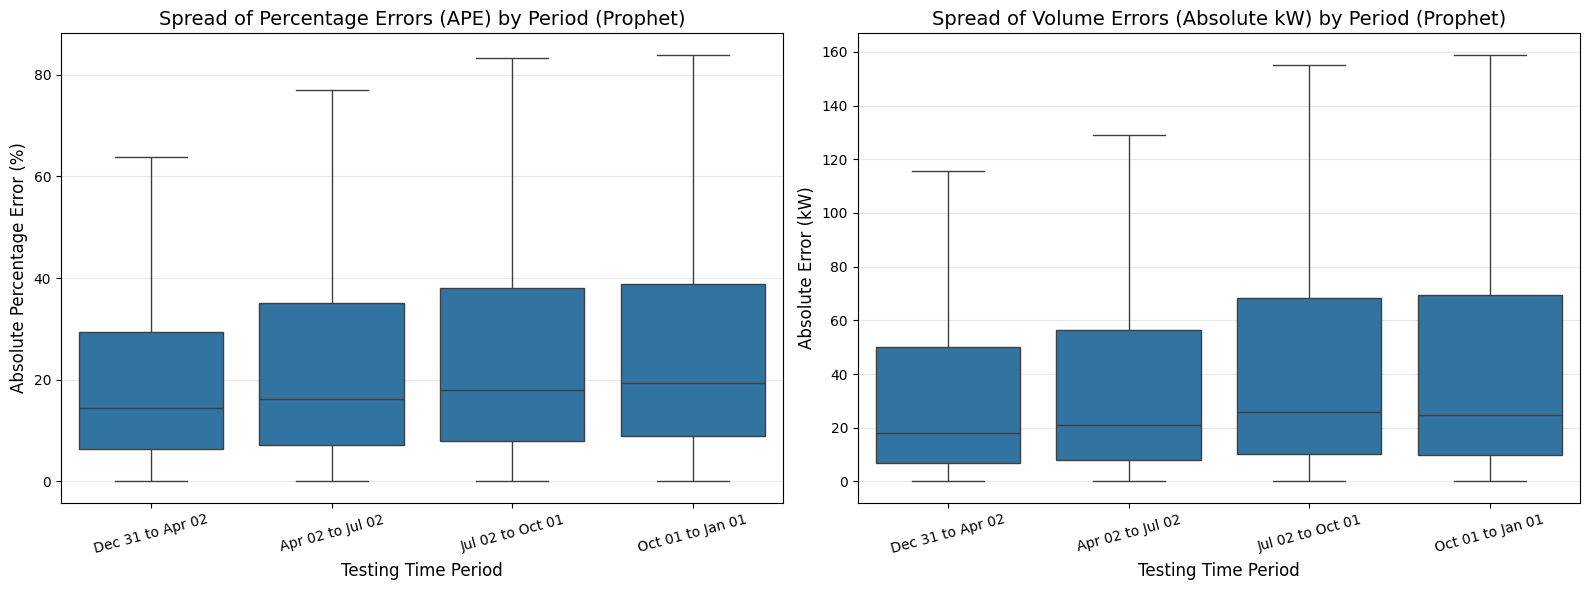

In [5]:
# Time Period Analysis & Error Spread
print("Preparing data for Time Period Analysis...")

# Create a clean evaluation dataframe from our raw test data
df_eval = df_test_raw.copy()
df_eval['Predicted_kW'] = np.nan

# Quickly reconstruct the predictions for all valid clients
for client in tqdm(df_eval['ClientID'].unique(), desc="Generating predictions for Box Plots"):
    mask = df_eval['ClientID'] == client
    
    # Skip if client has no data or no scaler
    if mask.sum() == 0 or client not in client_scalers:
        continue
        
    cluster_id = df_eval.loc[mask, 'Cluster'].values[0]
    if pd.isna(cluster_id):
        continue

    # Get generic scaled shape and unscale to raw kW
    pattern_forecast = cluster_forecasts[cluster_id][:mask.sum()]
    scaler = client_scalers[client]
    unscaled = scaler.inverse_transform(pattern_forecast.reshape(-1, 1)).flatten()
    
    # Floor to zero and save to the evaluation dataframe
    df_eval.loc[mask, 'Predicted_kW'] = np.maximum(unscaled, 0)

# Drop rows where we couldn't make a prediction
df_eval = df_eval.dropna(subset=['Consumption', 'Predicted_kW'])

# Sort chronologically to ensure periods are perfectly sequential
df_eval = df_eval.sort_values('Date')

# Extract the exact bin edges to create meaningful labels like "Jan 01 to Apr 02"
_, bin_edges = pd.cut(df_eval['Date'], bins=4, retbins=True)
bin_edges = pd.to_datetime(bin_edges) 
dynamic_labels = [f"{bin_edges[i].strftime('%b %d')} to {bin_edges[i+1].strftime('%b %d')}" for i in range(4)]

# Divide strictly into 4 equal time periods using the dynamic labels
df_eval['Time_Period'] = pd.cut(df_eval['Date'], bins=4, labels=dynamic_labels)

# --- CALCULATE ERRORS ROW BY ROW ---
# Calculate Absolute Error in raw kW
df_eval['Absolute_Error'] = np.abs(df_eval['Consumption'] - df_eval['Predicted_kW'])

# Calculate Absolute Percentage Error (APE)
# We filter out actual values close to zero to prevent infinity (division by zero)
valid_mask = df_eval['Consumption'] > 0.1
df_eval_valid = df_eval[valid_mask].copy()

df_eval_valid['APE'] = (df_eval_valid['Absolute_Error'] / df_eval_valid['Consumption']) * 100

# 1. Print the global MAPE for each period
print("\n--- MAPE BY TIME PERIOD (PROPHET) ---")
period_mape = df_eval_valid.groupby('Time_Period', observed=True)['APE'].mean()
for period, mape_val in period_mape.items():
    print(f"{period}:   {mape_val:.2f}%")

# Print the global WMAPE for each period
print("\n--- WMAPE BY TIME PERIOD (PROPHET) ---")
period_wmape = df_eval.groupby('Time_Period', observed=True).apply(
    lambda x: (x['Absolute_Error'].sum() / x['Consumption'].sum()) * 100
)
for period, wmape_val in period_wmape.items():
    print(f"{period}:   {wmape_val:.2f}%")

# 2. Plot the Box Plots (APE and Absolute Error in kW)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Absolute Percentage Error (APE)
sns.boxplot(data=df_eval_valid, x='Time_Period', y='APE', ax=axes[0], showfliers=False)
axes[0].set_title('Spread of Percentage Errors (APE) by Period (Prophet)', fontsize=14)
axes[0].set_ylabel('Absolute Percentage Error (%)', fontsize=12)
axes[0].set_xlabel('Testing Time Period', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=15)

# Plot 2: Absolute Error in raw kW
sns.boxplot(data=df_eval, x='Time_Period', y='Absolute_Error', ax=axes[1], showfliers=False)
axes[1].set_title('Spread of Volume Errors (Absolute kW) by Period (Prophet)', fontsize=14)
axes[1].set_ylabel('Absolute Error (kW)', fontsize=12)
axes[1].set_xlabel('Testing Time Period', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()